In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pyodbc

In [2]:
conexion = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=localhost\\SQLEXPRESS;'
    'DATABASE=AdventureWorks2022;'
    'UID=juanadmin;'
    'PWD=Juan.2511'
)

In [3]:
query = """
SELECT TOP 100
    pc.Name AS Categoria,
    p.Name AS Producto,
    SUM(sod.OrderQty) AS CantidadVendida,
    SUM(sod.LineTotal) AS TotalVenTAS,
    AVG(sod.UnitPrice) AS PrecioPromedio,
    MAX(sod.UnitPrice) AS PrecioMaximo,
    MIN(sod.UnitPrice) AS PrecioMinimo
FROM Sales.SalesOrderDetail sod
JOIN Production.Product p
    ON sod.ProductID = p.ProductID
JOIN Production.ProductSubcategory ps
    ON p.ProductSubcategoryID = ps.ProductSubcategoryID
JOIN Production.ProductCategory pc
    ON ps.ProductCategoryID = pc.ProductCategoryID
GROUP BY 
    pc.Name,
    p.Name
ORDER BY TotalVenTAS DESC;
"""

In [5]:
df = pd.read_sql(query, conexion)
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8936\1057015764.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


,Categoria,Producto,CantidadVendida,TotalVenTAS,PrecioPromedio,PrecioMaximo,PrecioMinimo
0,Bikes,"Mountain-200 Black, 38",2977,4.400593e+06,1730.1485,2294.99,1188.4770
1,Bikes,"Mountain-200 Black, 42",2664,4.009495e+06,1776.3198,2294.99,1127.0040
2,Bikes,"Mountain-200 Silver, 38",2394,3.693678e+06,1819.6183,2319.99,1201.4234
3,Bikes,"Mountain-200 Silver, 42",2234,3.438479e+06,1812.0157,2319.99,1201.4234
4,Bikes,"Mountain-200 Silver, 46",2216,3.434257e+06,1821.1371,2319.99,1201.4234


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Categoria        100 non-null    str    
 1   Producto         100 non-null    str    
 2   CantidadVendida  100 non-null    int64  
 3   TotalVenTAS      100 non-null    float64
 4   PrecioPromedio   100 non-null    float64
 5   PrecioMaximo     100 non-null    float64
 6   PrecioMinimo     100 non-null    float64
dtypes: float64(4), int64(1), str(2)
memory usage: 8.3 KB


In [7]:
df.describe()

,CantidadVendida,TotalVenTAS,PrecioPromedio,PrecioMaximo,PrecioMinimo
count,100.00000,1.000000e+02,100.000000,100.000000,100.000000
mean,1010.31000,9.978374e+05,1166.113005,1506.132444,795.423978
std,629.46719,8.746349e+05,786.180623,1026.617916,461.734288
min,322.00000,2.002845e+05,91.463800,120.000000,60.000000
25%,598.25000,3.508062e+05,509.621200,769.490000,419.458900
50%,794.00000,7.305895e+05,816.270350,874.794000,718.649600
75%,1246.00000,1.340103e+06,1813.916350,2384.070000,953.628000
max,3166.00000,4.400593e+06,3326.303700,3578.270000,2146.962000


In [8]:
total_ventas = df['TotalVenTAS'].sum()

producto_top = df.loc[
    df['TotalVenTAS'].idxmax(),
    "Producto"
]

categoria_top = df.groupby(
    "Categoria"
) ['TotalVenTAS'].sum().idxmax()

precio_promedio = df['PrecioPromedio'].mean()

print(f"Total de ventas: {total_ventas}")
print(f"Producto con mayor venta: {producto_top}")
print(f"Categoría Top: {categoria_top}")
print(f"Precio promedio: {precio_promedio}")

Total de ventas: 99783739.592808
Producto con mayor venta: Mountain-200 Black, 38
Categoría Top: Bikes
Precio promedio: 1166.113005


In [9]:
top10 = df.sort_values(
    by = 'TotalVenTAS',
    ascending = False
).head(10)

top10

,Categoria,Producto,CantidadVendida,TotalVenTAS,PrecioPromedio,PrecioMaximo,PrecioMinimo
0,Bikes,"Mountain-200 Black, 38",2977,4.400593e+06,1730.1485,2294.99,1188.4770
1,Bikes,"Mountain-200 Black, 42",2664,4.009495e+06,1776.3198,2294.99,1127.0040
2,Bikes,"Mountain-200 Silver, 38",2394,3.693678e+06,1819.6183,2319.99,1201.4234
3,Bikes,"Mountain-200 Silver, 42",2234,3.438479e+06,1812.0157,2319.99,1201.4234
4,Bikes,"Mountain-200 Silver, 46",2216,3.434257e+06,1821.1371,2319.99,1201.4234
5,Bikes,"Mountain-200 Black, 46",2111,3.309673e+06,1836.2179,2294.99,1188.4770
6,Bikes,"Road-250 Black, 44",1642,2.516857e+06,1745.1386,2443.35,1265.3063
7,Bikes,"Road-250 Black, 48",1498,2.347656e+06,1776.7649,2443.35,1265.3063
8,Bikes,"Road-250 Black, 52",1245,2.012448e+06,1823.7731,2443.35,1308.9375
9,Bikes,"Road-150 Red, 56",664,1.847819e+06,3035.8796,3578.27,2146.9620


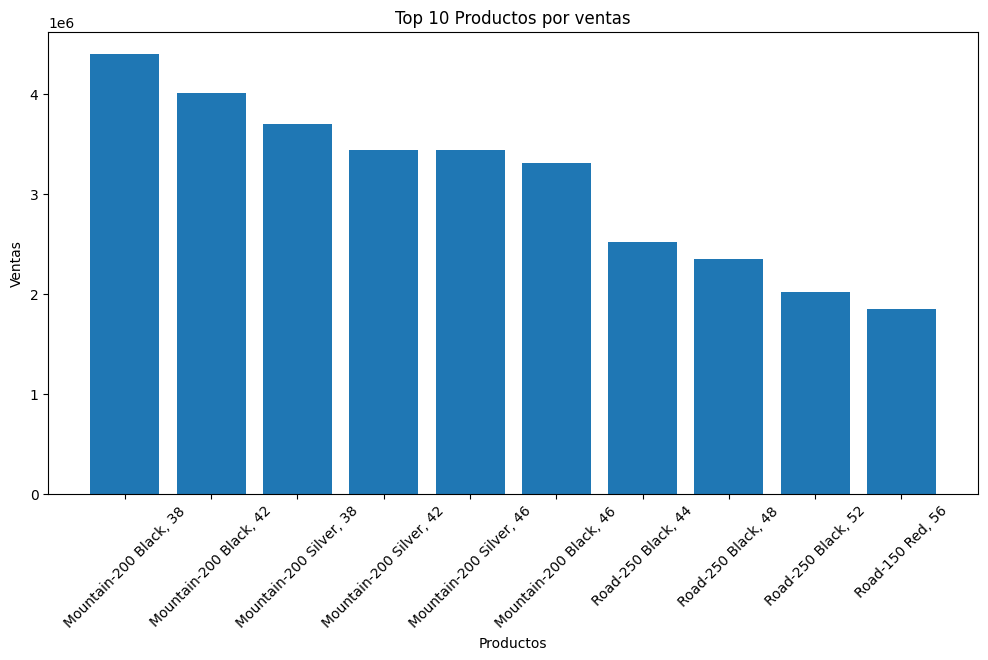

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(
    top10["Producto"],
    top10["TotalVenTAS"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Productos por ventas")

plt.xlabel("Productos")
plt.ylabel("Ventas")

plt.show()

In [11]:
ventas_categoria = df.groupby(
    'Categoria'
)['TotalVenTAS'].sum()

ventas_categoria

Categoria
Accessories    2.370962e+05
Bikes          9.258669e+07
Components     6.959954e+06
Name: TotalVenTAS, dtype: float64

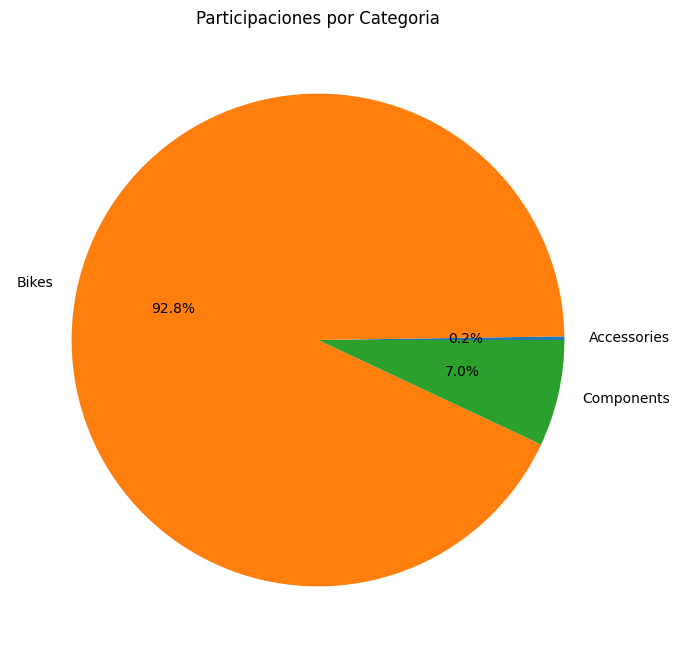

In [12]:
plt.figure(figsize=(8,8))

plt.pie(
    ventas_categoria,
    labels=ventas_categoria.index,
    autopct='%1.1f%%'
)

plt.title("Participaciones por Categoria")
plt.show()

In [13]:
df['Segmento'] = df['PrecioPromedio'].apply(
    lambda x:
        'Premium' if x > 1000
        else 'Intermedio' if x > 500
        else 'Económico'
)

df.head()

,Categoria,Producto,CantidadVendida,TotalVenTAS,PrecioPromedio,PrecioMaximo,PrecioMinimo,Segmento
0,Bikes,"Mountain-200 Black, 38",2977,4.400593e+06,1730.1485,2294.99,1188.4770,Premium
1,Bikes,"Mountain-200 Black, 42",2664,4.009495e+06,1776.3198,2294.99,1127.0040,Premium
2,Bikes,"Mountain-200 Silver, 38",2394,3.693678e+06,1819.6183,2319.99,1201.4234,Premium
3,Bikes,"Mountain-200 Silver, 42",2234,3.438479e+06,1812.0157,2319.99,1201.4234,Premium
4,Bikes,"Mountain-200 Silver, 46",2216,3.434257e+06,1821.1371,2319.99,1201.4234,Premium


In [14]:
df['Segmento'].value_counts()

Segmento
Premium       39
Intermedio    36
Económico     25
Name: count, dtype: int64

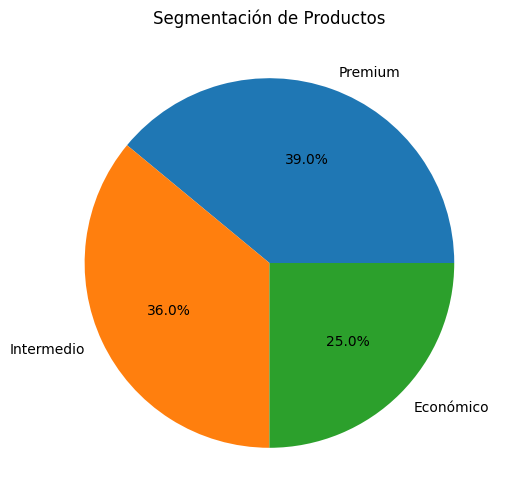

In [15]:
segmentos = df['Segmento'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    segmentos,
    labels=segmentos.index,
    autopct='%1.1f%%'
)

plt.title("Segmentación de Productos")
plt.show()

In [16]:
df.to_excel(
    "../exports/reportes_excel/producto_categoria.xlsx"
)

print("Reporte exportado exitosamente.")

Reporte exportado exitosamente.
